# Relevância de Congonhas nas decolagens nacionais (VRA/ANAC, 2025)

Quantifica a participação do Aeroporto de Congonhas (SBSP) no total de decolagens de
voos comerciais regulares do país em 2025, a partir dos registros de **Voo Regular
Ativo (VRA)** da ANAC — uma medida da relevância do aeroporto no cenário nacional.

## Fonte

- Registros de Voo Regular Ativo (VRA) da ANAC — portal de dados abertos.
- Arquivos locais: `data/vra/VRA_2025*.csv` (doze arquivos mensais), baixados no
  notebook `0_2_download_var`.
- Cada arquivo traz uma linha de metadado no topo (`Atualizado em: ...`); o cabeçalho
  real usa `;` como separador.

In [2]:
# pip install pandas
# pip install matplotlib

In [3]:
import glob
import pandas as pd
import matplotlib.pyplot as plt

## 0.4.1 Carregamento do VRA nacional de 2025

Leitura dos doze arquivos mensais. Pula-se a primeira linha (metadado), lê-se com
separador `;` e mantêm-se apenas as colunas necessárias — aeroporto de origem,
situação do voo e partida real. Consideram-se apenas os voos **realizados**; cada
registro corresponde a uma **decolagem** (o voo parte do seu aeroporto de origem).

In [9]:
COL_ORIGEM = "ICAO Aeródromo Origem"
COL_SITUACAO = "Situação Voo"
COL_PARTIDA = "Partida Real"

arquivos = sorted(glob.glob("data/vra/VRA_2025*.csv"))
partes = []
for arq in arquivos:
    df = pd.read_csv(
        arq, sep=";", skiprows=1, dtype=str,
        usecols=[COL_ORIGEM, COL_SITUACAO, COL_PARTIDA],
    )
    partes.append(df)

vra = pd.concat(partes, ignore_index=True)
vra = vra[vra[COL_SITUACAO].str.upper() == "REALIZADO"].copy()
vra["data"] = vra[COL_PARTIDA].str[:10]

print(f"{len(arquivos)} arquivos | {len(vra):,} decolagens realizadas em 2025")
vra.head()

12 arquivos | 978,092 decolagens realizadas em 2025


,ICAO Aeródromo Origem,Partida Real,Situação Voo,data
0,SBGR,2025-01-17 01:53:00,REALIZADO,2025-01-17
1,SBGR,2025-01-18 03:20:00,REALIZADO,2025-01-18
2,SBGR,2025-01-19 02:11:00,REALIZADO,2025-01-19
3,SBGR,2025-01-20 03:24:00,REALIZADO,2025-01-20
5,LEMD,2025-01-01 20:26:00,REALIZADO,2025-01-01


## 0.4.2 Participação de Congonhas e ranking nacional

Contagem de decolagens por aeroporto de origem. A participação de Congonhas é a razão
entre suas decolagens e o total nacional; o ranking ordena os aeroportos por volume.

In [10]:
total = len(vra)
por_aeroporto = vra[COL_ORIGEM].value_counts()

sbsp = int(por_aeroporto["SBSP"])
participacao = sbsp / total * 100
posicao = por_aeroporto.index.get_loc("SBSP") + 1

print(f"Total de decolagens no país (2025): {total:,}")
print(f"Decolagens de Congonhas (SBSP):     {sbsp:,}")
print(f"Participação de Congonhas:          {participacao:.2f}%")
print(f"Posição no ranking nacional:        {posicao}º")

ranking = (
    por_aeroporto.head(8)
    .rename_axis("aeroporto")
    .reset_index(name="decolagens")
)
ranking["participacao_%"] = (ranking["decolagens"] / total * 100).round(2)
ranking

Total de decolagens no país (2025): 978,092
Decolagens de Congonhas (SBSP):     93,370
Participação de Congonhas:          9.55%
Posição no ranking nacional:        2º


,aeroporto,decolagens,participacao_%
0,SBGR,143712,14.69
1,SBSP,93370,9.55
2,SBKP,61349,6.27
3,SBGL,58870,6.02
4,SBBR,58347,5.97
5,SBCF,57948,5.92
6,SBRF,37321,3.82
7,SBSV,28760,2.94


## 0.4.3 Média diária de decolagens em Congonhas

Média de decolagens por dia em Congonhas ao longo do ano.

In [13]:
sbsp_por_dia = vra.loc[vra[COL_ORIGEM] == "SBSP"].groupby("data").size()
media_dia = sbsp_por_dia.mean()

print(f"Dias com operação: {len(sbsp_por_dia)}")
print(f"Média de decolagens da aviação comercial por dia em Congonhas: {media_dia:.1f}")

Dias com operação: 365
Média de decolagens da aviação comercial por dia em Congonhas: 255.8


## 0.4.4 Aeroportos com mais decolagens no país

Os oito aeroportos de maior volume, com Congonhas destacado.

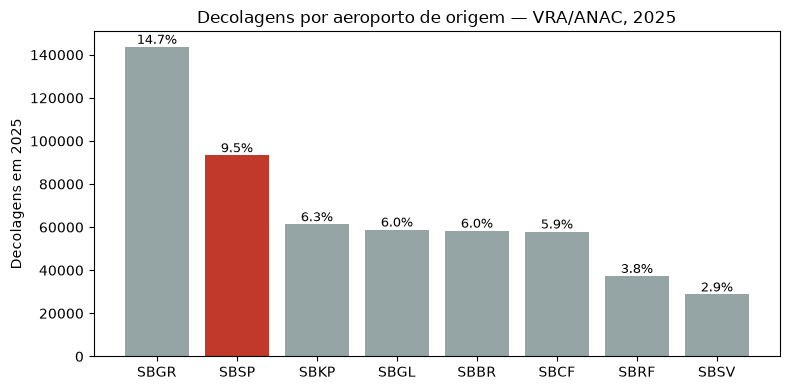

In [14]:
cores = ["#c0392b" if a == "SBSP" else "#95a5a6" for a in ranking["aeroporto"]]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(ranking["aeroporto"], ranking["decolagens"], color=cores)
ax.set_ylabel("Decolagens em 2025")
ax.set_title("Decolagens por aeroporto de origem — VRA/ANAC, 2025")
for a, v in zip(ranking["aeroporto"], ranking["decolagens"]):
    ax.text(a, v, f"{v / total * 100:.1f}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

## 0.4.5 Síntese

In [15]:
print(
    f"Em 2025, Congonhas (SBSP) foi o {posicao}º aeroporto do país em decolagens de "
    f"voos comerciais regulares, com {sbsp:,} partidas "
    f"({participacao:.1f}% do total nacional; média de ~{media_dia:.0f} por dia)."
)

Em 2025, Congonhas (SBSP) foi o 2º aeroporto do país em decolagens de voos comerciais regulares, com 93,370 partidas (9.5% do total nacional; média de ~256 por dia).
